In [1]:
import datetime
import json
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import xarray as xr
import yaml

from pcse.base import ParameterProvider
from pcse.input import YAMLCropDataProvider
from pcse.util import wind10to2
from diffwofost.physical_models.base.weather import TensorWeatherDataProvider
from diffwofost.physical_models.config import Configuration
from diffwofost.physical_models.crop.phenology import DVS_Phenology
from diffwofost.physical_models.engine import Engine

# Phenology simulation with diffWOFOST

This notebook re-implements the simulation of phenology illustrated in [this notebook](https://github.com/artofmodelling/phenomodelling/blob/main/phenology_modelling.ipynb) with diffWOFOST. 

We first clone the repository hosting the phenomodelling notebook, as it includes the required data as well:

In [ ]:
!if [ ! -d phenomodelling ] ; then git clone https://github.com/artofmodelling/phenomodelling.git ; fi

Cloning into 'phenomodelling'...
remote: Enumerating objects: 93, done.
remote: Counting objects: 100% (93/93), done.
remote: Compressing objects: 100% (35/35), done.
remote: Total 93 (delta 69), reused 79 (delta 58), pack-reused 0 (from 0)
Receiving objects: 100% (93/93), 18.79 MiB | 20.38 MiB/s, done.
Resolving deltas: 100% (69/69), done.


Let's load the phenological observations:

In [3]:
def load_observations():
    """Load observation data."""
    df = pd.read_excel("phenomodelling/data/pheno_obs_1784.xlsx", sheet_name="data")
    return df[df.VALID]

In [4]:
observations = load_observations()

In [5]:
observations.head()

,ObjectID,Longitude,Latitude,DOS,DOA,DOM,DOH,VALID
0,Spring Barley_2010_-0.7_53.87_86565,-0.700067,53.869820,2010-03-19,NaT,2010-08-19,2010-10-15,True
1,Spring Barley_2010_-2.588_55.51_86548,-2.587734,55.510104,2010-04-12,NaT,2010-08-18,NaT,True
2,Spring Barley_2011_-2.988_52.28_89360,-2.988059,52.279508,2011-03-22,2011-06-16,2011-08-21,2011-08-23,True
3,Spring Barley_2011_-3.144_55.727_86748,-3.143778,55.726719,2011-04-18,2011-07-23,NaT,NaT,True
5,Spring Barley_2012_-3.046_55.919_86978,-3.046074,55.919286,2012-03-02,NaT,2012-08-27,NaT,True


We then load the weather data corresponding to the observations:

In [ ]:
variable_renaming = [
    ("temperature_max", "TMAX", None),
    ("temperature_min", "TMIN", None),
    ("temperature_avg",  "TEMP", None),
    ("vapourpressure", "VAP", None),
    ("windspeed", "WIND", wind10to2),
    ("precipitation", "RAIN", lambda x: x/10.),
    ("radiation", "IRRAD", lambda x: x*1000.),
    ("snowdepth", "SNOWDEPTH", None),
    ("day", "DAY", None)
]

def load_weather_data_file(object_id):
    """Load weather data for a given location from the corresponding JSON file."""

    with open(f"phenomodelling/data/meteo/{object_id}.json") as f:
        d = json.load(f)

    data = d["data"]

    df = pd.DataFrame(data["weather_variables"])

    # Parse location information
    location_info = data["location_info"]
    lon = float(location_info["grid_agera5_longitude"])
    lat = float(location_info["grid_agera5_latitude"])
    elev = float(location_info["grid_agera5_elevation"])

    # Rename columns and apply unit corrections
    rename_cols = {old_name: new_name for old_name, new_name, _ in variable_renaming}
    convert_cols = {new_name: conversion for _, new_name, conversion in
                    variable_renaming if conversion is not None}
    df = df.rename(columns=rename_cols)
    for column, conv in convert_cols.items():
        df[column] = df[column].apply(conv)

    df.DAY = pd.to_datetime(df.DAY)
    return df, lon, lat, elev


def load_weather_data(object_ids):
    """Load weather data for all locations."""
    dfs = []
    nlocations = len(object_ids)
    lon = np.zeros(nlocations)
    lat = np.zeros(nlocations)
    elev = np.zeros(nlocations)

    # Load data for all locations
    for n, object_id in enumerate(object_ids):
        df, lon[n], lat[n], elev[n] = load_weather_data_file(object_id=object_id)
        df = df.set_index("DAY")
        dfs.append(df)

    # Merge data in a dataset
    ds = xr.concat(
        [xr.Dataset.from_dataframe(df) for df in dfs],
        dim="location"
    )

    # Add location information to the dataset
    ds.coords["LON"] = xr.DataArray(lon, dims="location")
    ds.coords["LAT"] = xr.DataArray(lat, dims="location")
    ds["ELEV"] = xr.DataArray(elev, dims="location")
    return ds

In [7]:
weather_data = load_weather_data(observations["ObjectID"])

In [8]:
weather_data

<xarray.Dataset> Size: 15MB
Dimensions:    (location: 41, DAY: 5234)
Coordinates:
  * DAY        (DAY) datetime64[us] 42kB 2010-01-01 2010-01-02 ... 2024-04-30
    LON        (location) float64 328B -0.75 -2.55 -2.95 ... -7.05 -8.35 -7.05
    LAT        (location) float64 328B 53.85 55.55 52.25 ... 52.35 52.15 52.55
Dimensions without coordinates: location
Data variables:
    idgrid     (location, DAY) int64 2MB 5178592 5178592 ... 5131729 5131729
    TMAX       (location, DAY) float64 2MB 0.7736 2.148 1.086 ... 13.99 11.49
    TMIN       (location, DAY) float64 2MB -2.119 -2.754 -2.795 ... 6.517 7.682
    TEMP       (location, DAY) float64 2MB -0.1971 -0.02729 ... 10.36 8.895
    VAP        (location, DAY) float64 2MB 5.374 5.225 4.916 ... 10.3 10.01
    WIND       (location, DAY) float64 2MB 1.937 1.993 1.323 ... 2.364 2.041
    RAIN       (location, DAY) float64 2MB 0.118 0.174 0.015 ... 0.729 0.79
    IRRAD      (location, DAY) float64 2MB 2.159e+06 2.064e+06 ... 1.232e+07
    SNOWDEPTH  (location, DAY) float64 2MB 0.1 0.1 0.1 0.1 ... 1.76 7.29 7.9
    ELEV       (location) float64 328B 1.7 231.3 265.8 ... 67.6 105.7 113.8

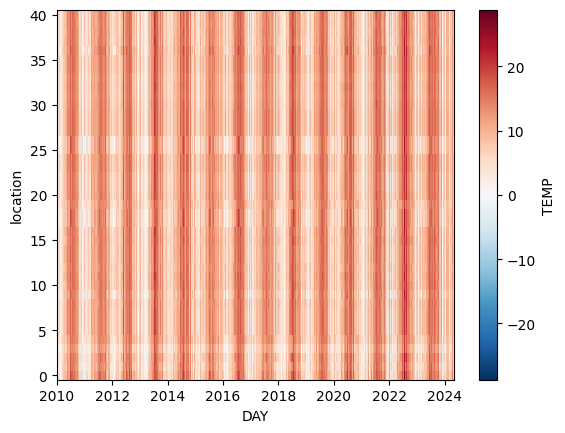

In [9]:
weather_data["TEMP"].plot.imshow()

We preprocess the weather data by computing the daylength from latitude and day of the year:

In [10]:
def doy(day):
    """Converts a date or datetime object to day-of-year (Jan 1st = doy 1)."""
    # Check if day is a date or datetime object
    if isinstance(day, (datetime.date, datetime.datetime)):
        return day.timetuple().tm_yday
    elif isinstance(day, np.ndarray):
        day_series = pd.Series(np.ravel(day), copy=False)
        day_of_year = day_series.dt.day_of_year.values
        return day_of_year.reshape(day.shape)
    else:
        raise TypeError(f"Cannot calculate day-of-year from object of type: {type(day)}")


def daylength(day, latitude, angle=-4, outer=True):
    """Numpy-vectorized daylength calculation for a given day, latitude and base angle."""
    # if outer, all possible combinations of day and latitude are considered
    if outer:
        multiply = np.multiply.outer
    else:
        multiply = np.multiply

    # Check for range of latitude and convert to radians
    if (abs(latitude) > 90.0).any():
        msg = "Latitude not between -90 and 90"
        raise RuntimeError(msg)
    latitude_rad = np.radians(latitude)

    # Calculate day-of-year from date object day
    iday = doy(day)

    # calculate daylength
    dec = -np.asin(np.sin(np.radians(23.45)) * np.cos(2.0 * np.pi * (iday + 10.0) / 365.0))
    sinld = multiply(np.sin(latitude_rad), np.sin(dec))
    cosld = multiply(np.cos(latitude_rad), np.cos(dec))
    aob = (-np.sin(np.radians(angle)) + sinld) / cosld

    # daylength — replace scalar if/elif/else with torch.where for batched support
    aob_clipped = np.clip(aob, -1.0, 1.0)
    daylp = 12.0 * (1.0 + 2.0 * np.asin(aob_clipped) / np.pi)
    daylp = np.where(aob < -1.0, 0.0, daylp)
    daylp = np.where(aob > 1.0, 24.0, daylp)
    return daylp

In [ ]:
weather_data["DAYLENGTH"] = xr.DataArray(
    daylength(weather_data.DAY.data, weather_data.LAT.data),
    dims=("location", "DAY")
)

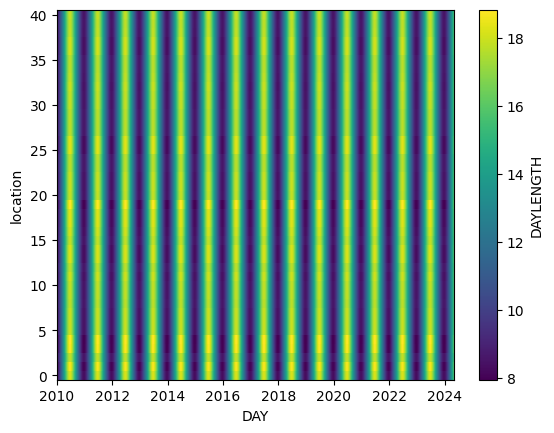

In [12]:
weather_data["DAYLENGTH"].plot.imshow()

For all locations, simulations consider a selected number of days (here 300) that follow the date of sowing (DOS):

In [ ]:
NDAYS = 300  # Max simulated days
DOS = xr.DataArray(observations.DOS.values, dims="location")
delta = np.array(NDAYS, np.dtype('timedelta64[D]'))
mask = (weather_data["DAY"] >= DOS) & (weather_data["DAY"] < DOS + delta)

All the remaining weather data can be masked out, e.g.:

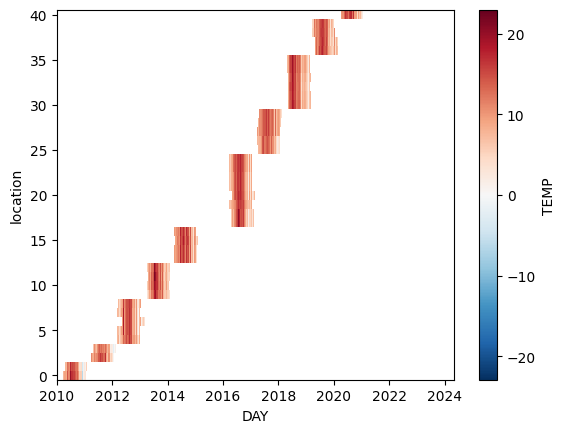

In [14]:
TEMP = weather_data["TEMP"].where(mask)
TEMP.plot.imshow()

We can thus extract drop these masked values from the dataset, effectively setting the zero along the time axis on the DOS: 

In [15]:
def extract_days(data, day, dos):
    """Extract days from DOS to DOS + delta."""
    indices = np.where((day >= dos) & (day < dos + delta))
    return np.take(data, indices)

selected = xr.apply_ufunc(
    extract_days,
    weather_data[["TEMP", "DAYLENGTH"]],
    weather_data["DAY"],
    DOS,
    input_core_dims=[["DAY"], ["DAY"], []],
    output_core_dims=[["day"]],
    vectorize=True
)

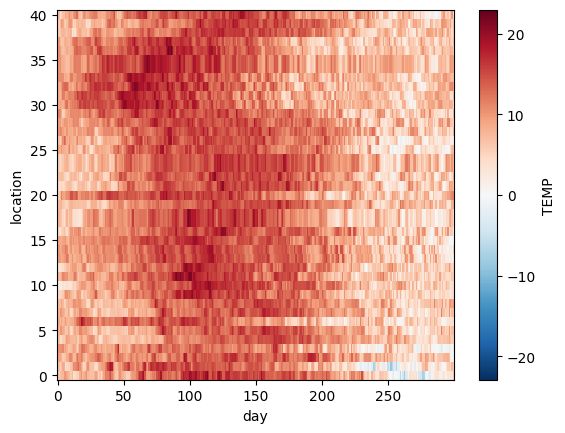

In [16]:
selected["TEMP"].plot.imshow()

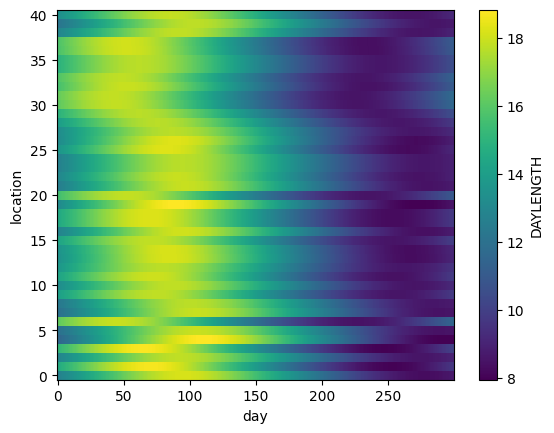

In [17]:
selected["DAYLENGTH"].plot.imshow()

We now assign fictitious date labels to the time axis: 

In [18]:
START_DATE = "1900-01-01"
selected["day"] = ("day", pd.date_range(START_DATE, periods=NDAYS))
selected = selected.set_coords("day")

And define an derived class to be able to use easily access tensor weather data in diffWOFOST: 

In [19]:
class XarrayWeatherDataProvider(TensorWeatherDataProvider):
    def _get_variable_shape(self):
        return self.store.isel(day=0).TEMP.shape

    def _get_variables(self, day):
        store = self.store.sel(day=str(day))
        vars = {k: store[k].data for k in ("TEMP", "DAYLENGTH")}
        return vars

In [20]:
wdp = XarrayWeatherDataProvider(store=selected, meteo_range_checks=False)

We now define the other required elements to run a simulation, i.e. the parameter provider:

In [21]:
from pcse.base import ParameterProvider
from pcse.input import YAMLCropDataProvider

cropd = YAMLCropDataProvider()
params = ParameterProvider(cropdata=cropd)

the model configuration:

In [22]:
phenology_config = Configuration(
    CROP=DVS_Phenology,
    OUTPUT_VARS=["DVS", "STAGE", "DOS", "DOA", "DOM"],
)

and the agromanagement (note that we use the fictitious starting date here):

In [23]:
agro_yaml = f"""
- {START_DATE}:
    CropCalendar:
        crop_name: barley
        variety_name: Spring_barley_301
        crop_start_date: {START_DATE}
        crop_start_type: sowing
        crop_end_date:
        crop_end_type: maturity
        max_duration: 600
    TimedEvents:
    StateEvents:
"""
agro = yaml.safe_load(agro_yaml)

We can finally setup the engine and run the phenology simulation for all locations in one execution:

In [24]:
engine = Engine(config=phenology_config)
engine.setup(
    parameterprovider=params,
    weatherdataprovider=wdp,
    agromanagement=agro,
)
engine.run_till_terminate()
out = engine.get_output()

Visualizing the output (different colors refer to different locations):

Text(0.5, 0, 'day')

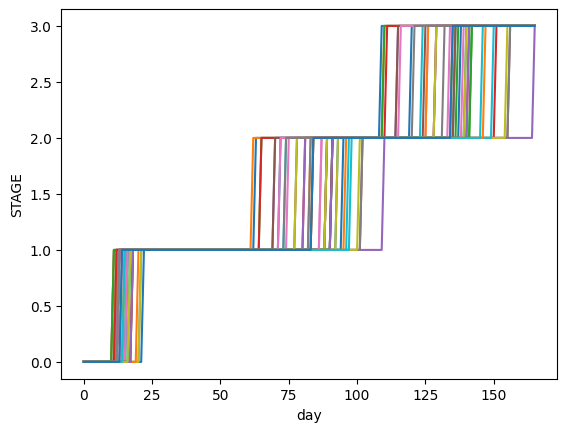

In [25]:
import matplotlib.pyplot as plt
plt.plot(torch.stack([el["STAGE"] for el in out]))
plt.ylabel("STAGE")
plt.xlabel("day")

From the last time step of the simulation, we can extract the simulated dates of anthesis (DOA) and dates of maturity (DOM), and compute the corresponding deltas:

In [26]:
final = out[-1] # last time step of simulation
days_to_anthesis_sim = np.asarray(final["DOA"] - final["DOS"])
days_to_maturity_sim = np.asarray(final["DOM"] - final["DOS"])

Some post-processing of observations, e.g. to estimated maturity from harvest by subtracting 7 days:

In [27]:
# Estimate maturity from harvest if DOM is null
days_to_harvest = 7
ix = pd.isna(observations.DOM)
observations.loc[ix, "DOM"] = observations.loc[ix,"DOH"] - pd.Timedelta(days_to_harvest, unit="days")
days_to_anthesis_obs = (observations.DOA - observations.DOS).dt.days
days_to_maturity_obs = (observations.DOM - observations.DOS).dt.days

Visualize the comparison of observations with simulations:

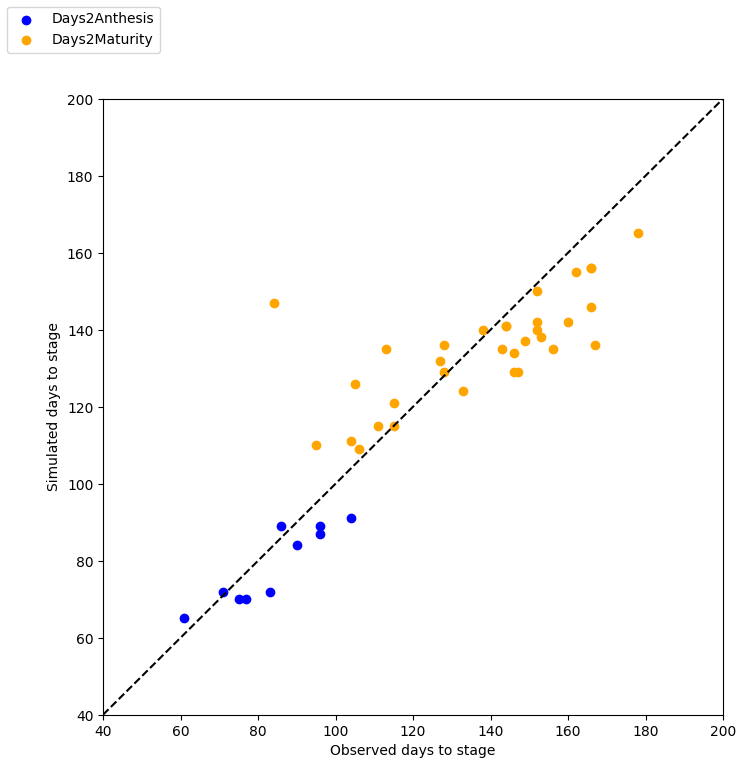

In [28]:
fig, axes = plt.subplots(figsize=(8,8))
ix = pd.isna(days_to_anthesis_obs)
axes.scatter(days_to_anthesis_obs[~ix], days_to_anthesis_sim[~ix], label="Days2Anthesis", color='blue', marker="o")
ix = pd.isna(days_to_maturity_obs)
axes.scatter(days_to_maturity_obs[~ix], days_to_maturity_sim[~ix], label="Days2Maturity", color='orange', marker="o")
limits = [40, 200]
axes.set_xlabel("Observed days to stage")
axes.set_ylabel("Simulated days to stage")
axes.set_xlim(limits)
axes.set_ylim(limits)
axes.plot(limits, limits, marker="", linestyle="--", color='black')
r = fig.legend(loc=2)